Epoch     0 | Loss = 4.952e+01 | Data = 1.286e-01 | Phys = 1.033e+00 | Omega_m = 0.4995 | Omega_L = 0.5005
Epoch  1000 | Loss = 4.559e-02 | Data = 6.212e-05 | Phys = 3.351e-03 | Omega_m = 0.3196 | Omega_L = 0.6804
Epoch  2000 | Loss = 8.859e-03 | Data = 5.277e-05 | Phys = 2.978e-04 | Omega_m = 0.2989 | Omega_L = 0.7011
Epoch  3000 | Loss = 7.181e-03 | Data = 5.942e-05 | Phys = 9.570e-05 | Omega_m = 0.3021 | Omega_L = 0.6979
Epoch  4000 | Loss = 6.917e-03 | Data = 6.269e-05 | Phys = 4.287e-05 | Omega_m = 0.3034 | Omega_L = 0.6966
Epoch  5000 | Loss = 5.748e-03 | Data = 5.440e-05 | Phys = 2.156e-05 | Omega_m = 0.3038 | Omega_L = 0.6962
Epoch  6000 | Loss = 5.711e-03 | Data = 5.428e-05 | Phys = 1.990e-05 | Omega_m = 0.3040 | Omega_L = 0.6960
Epoch  7000 | Loss = 5.700e-03 | Data = 5.429e-05 | Phys = 1.892e-05 | Omega_m = 0.3040 | Omega_L = 0.6960
Epoch  8000 | Loss = 5.697e-03 | Data = 5.432e-05 | Phys = 1.848e-05 | Omega_m = 0.3041 | Omega_L = 0.6959
Epoch  9000 | Loss = 5.697e-03 | Data

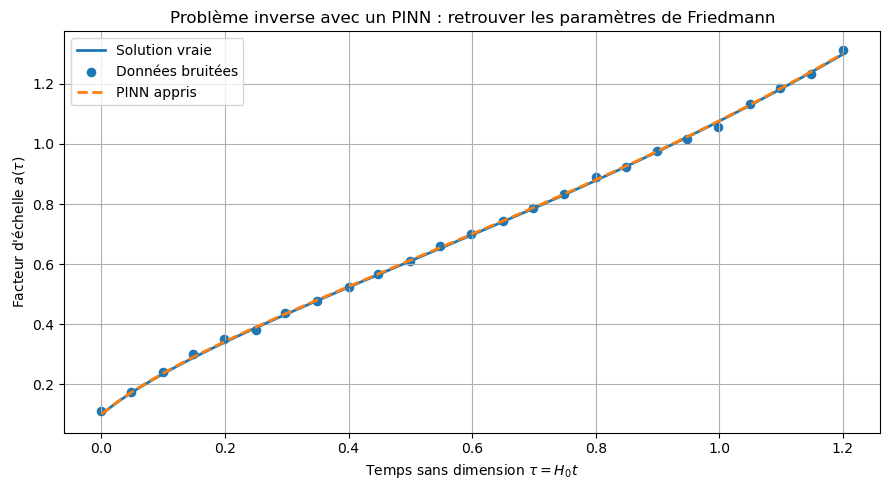

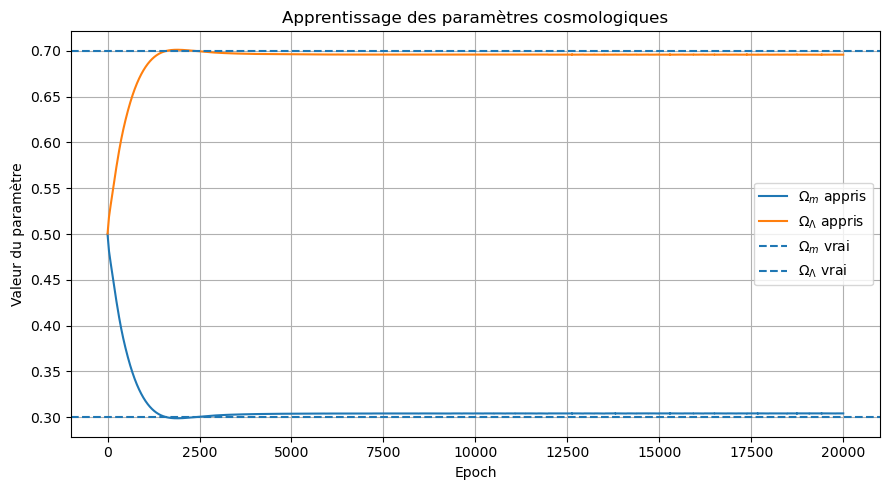

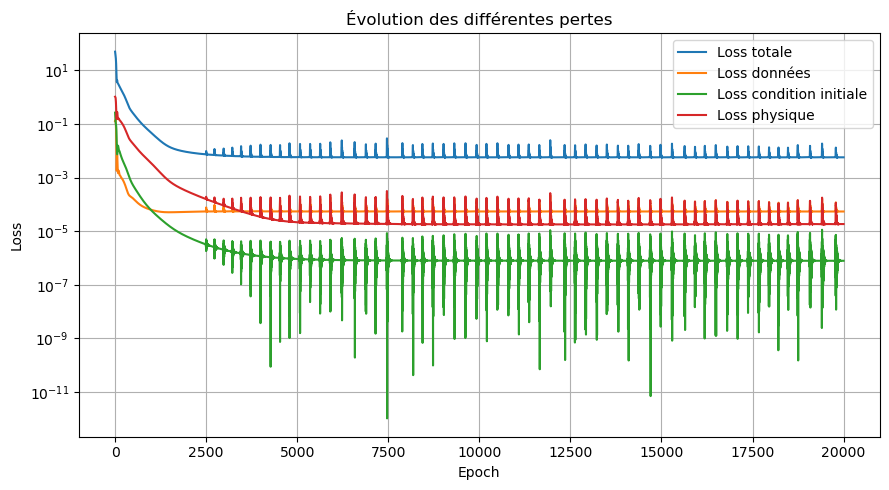

In [6]:

# PINN inverse pour les équations de Friedmann
# Objectif :
#   retrouver Omega_m et Omega_Lambda à partir de données bruitées
#   de a(tau), en imposant l'équation de Friedmann.
# Model jouet pour la pedagogie 


import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


# 1) Paramètres physiques du problème


torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Valeurs vraies, utilisées seulement pour fabriquer des fausses données
Omega_m_true = 0.30
Omega_L_true = 0.70

# Condition initiale : facteur d'échelle initial
a_init = 0.10

# Temps final sans dimension tau = H0 t
T = 1.2


# 2) Solution analytique pour générer des données synthétiques

# Pour un Univers plat matière + Lambda, on peut écrire une solution
# analytique. Ici elle sert uniquement à produire des "observations".
# Dans une vraie application, ces données viendraient de supernovae,
# BAO, H(z), CMB, etc.

def solution_friedmann_plate(tau, Omega_m, Omega_L, a0):
    
    C = np.arcsinh(np.sqrt(Omega_L / Omega_m) * a0**1.5)

    a_tau = (Omega_m / Omega_L)**(1/3) * np.sinh(
        1.5 * np.sqrt(Omega_L) * tau + C
    )**(2/3)

    return a_tau


# Grille fine pour la solution de référence
tau_ref = np.linspace(0, T, 400).reshape(-1, 1)
a_ref = solution_friedmann_plate(
    tau_ref,
    Omega_m_true,
    Omega_L_true,
    a_init
)


# 3) Création de données observées bruitées et incomplètes


N_data = 25

indices = np.linspace(0, len(tau_ref) - 1, N_data, dtype=int)

tau_data = tau_ref[indices]
a_data_clean = a_ref[indices]

# Bruit expérimental artificiel
noise_level = 0.02
noise = noise_level * np.std(a_data_clean) * np.random.randn(*a_data_clean.shape)

a_data_noisy = a_data_clean + noise


# Conversion en tenseurs PyTorch
tau_data_t = torch.tensor(tau_data, dtype=torch.float32).to(device)
a_data_t = torch.tensor(a_data_noisy, dtype=torch.float32).to(device)

# Points de collocation : points où l'on impose la physique
N_col = 150

tau_col = torch.linspace(0, T, N_col).view(-1, 1).to(device)
tau_col.requires_grad_(True)

# Condition initiale
tau0 = torch.tensor([[0.0]], dtype=torch.float32).to(device)
a0 = torch.tensor([[a_init]], dtype=torch.float32).to(device)



# 4) Définition du réseau de neurones


class FriedmannPINN(nn.Module):
    def __init__(self):
        super().__init__()

        # Réseau qui prend tau en entrée et prédit a(tau)
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

        # Paramètres cosmologiques inconnus.
        # Le réseau va les apprendre.
        #
        # On utilise deux paramètres libres, puis un softmax pour imposer :
        #   Omega_m > 0
        #   Omega_Lambda > 0
        #   Omega_m + Omega_Lambda = 1
        self.raw_omega = nn.Parameter(torch.tensor([0.0, 0.0]))

    def forward(self, tau):
        """
        Prédit a(tau).

        On impose a(tau) > 0 avec softplus, car le facteur d'échelle
        cosmologique ne peut pas être négatif.
        """
        raw_output = self.net(tau)
        a_pred = 1e-4 + F.softplus(raw_output)

        return a_pred

    def get_omegas(self):
        """
        Retourne Omega_m et Omega_Lambda appris par le modèle.
        """
        omegas = F.softmax(self.raw_omega, dim=0)

        Omega_m = omegas[0]
        Omega_L = omegas[1]

        return Omega_m, Omega_L


model = FriedmannPINN().to(device)


# 5) Fonction de perte du PINN

def pinn_loss():
    # A) Loss sur les données

    
    a_pred_data = model(tau_data_t)

    loss_data = torch.mean((a_pred_data - a_data_t)**2)

    
    # B) Loss sur la condition initiale
    
    a_pred_0 = model(tau0)

    loss_ic = torch.mean((a_pred_0 - a0)**2)

    
    # C) Loss physique : équation de Friedmann

    
    a_pred_col = model(tau_col)

    # Dérivée da/dtau calculée automatiquement par PyTorch
    
    da_dtau = torch.autograd.grad(
        a_pred_col,
        tau_col,
        grad_outputs=torch.ones_like(a_pred_col),
        create_graph=True
    )[0]

    Omega_m, Omega_L = model.get_omegas()

    rhs = torch.sqrt(Omega_m / a_pred_col + Omega_L * a_pred_col**2 + 1e-8)

    residual = da_dtau - rhs

    loss_phys = torch.mean(residual**2)

    
    # D) Loss totale
    
    lambda_data = 100.0
    lambda_ic = 100.0
    lambda_phys = 10.0

    loss_total = (
        lambda_data * loss_data
        + lambda_ic * loss_ic
        + lambda_phys * loss_phys
    )

    return loss_total, loss_data, loss_ic, loss_phys



# 6) Entraînement


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20000

history_total = []
history_data = []
history_ic = []
history_phys = []
history_Omega_m = []
history_Omega_L = []

for epoch in range(epochs + 1):
    optimizer.zero_grad()

    loss_total, loss_data, loss_ic, loss_phys = pinn_loss()

    loss_total.backward()
    optimizer.step()

    Omega_m_learned, Omega_L_learned = model.get_omegas()

    history_total.append(loss_total.item())
    history_data.append(loss_data.item())
    history_ic.append(loss_ic.item())
    history_phys.append(loss_phys.item())
    history_Omega_m.append(Omega_m_learned.item())
    history_Omega_L.append(Omega_L_learned.item())

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss_total.item():.3e} | "
            f"Data = {loss_data.item():.3e} | "
            f"Phys = {loss_phys.item():.3e} | "
            f"Omega_m = {Omega_m_learned.item():.4f} | "
            f"Omega_L = {Omega_L_learned.item():.4f}"
        )


# 7) Résultats




Omega_m_final, Omega_L_final = model.get_omegas()

print("\n RESULTATS ")
print(f"Omega_m vrai      = {Omega_m_true:.4f}")
print(f"Omega_m appris    = {Omega_m_final.item():.4f}")
print()
print(f"Omega_L vrai      = {Omega_L_true:.4f}")
print(f"Omega_L appris    = {Omega_L_final.item():.4f}")




# 8) Prédiction du réseau

tau_plot = torch.tensor(tau_ref, dtype=torch.float32).to(device)

with torch.no_grad():
    a_pinn = model(tau_plot).cpu().numpy()



# 9) Graphique : données, solution vraie, solution PINN

plt.figure(figsize=(9, 5))

plt.plot(tau_ref, a_ref, label="Solution vraie", linewidth=2)
plt.scatter(tau_data, a_data_noisy, label="Données bruitées", s=35)
plt.plot(tau_ref, a_pinn, "--", label="PINN appris", linewidth=2)

plt.xlabel(r"Temps sans dimension $\tau = H_0 t$")
plt.ylabel(r"Facteur d'échelle $a(\tau)$")
plt.title("Problème inverse avec un PINN : retrouver les paramètres de Friedmann")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# 10) Graphique : évolution des paramètres appris

plt.figure(figsize=(9, 5))

plt.plot(history_Omega_m, label=r"$\Omega_m$ appris")
plt.plot(history_Omega_L, label=r"$\Omega_\Lambda$ appris")

plt.axhline(Omega_m_true, linestyle="--", label=r"$\Omega_m$ vrai")
plt.axhline(Omega_L_true, linestyle="--", label=r"$\Omega_\Lambda$ vrai")

plt.xlabel("Epoch")
plt.ylabel("Valeur du paramètre")
plt.title("Apprentissage des paramètres cosmologiques")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# 11) Graphique : évolution des pertes

plt.figure(figsize=(9, 5))

plt.semilogy(history_total, label="Loss totale")
plt.semilogy(history_data, label="Loss données")
plt.semilogy(history_ic, label="Loss condition initiale")
plt.semilogy(history_phys, label="Loss physique")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Évolution des différentes pertes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()